<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>99101 עיבוד שפה טבעית NLP</p>
<p>פרויקט סיום</p>
<p>שם: נדב פיירמן שטרן</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גילוי נאות על שימוש ב-AI</p>

<p>כלים, משימות והיקף</p>
<ul>
<li>Claude - הכלי המרכזי, בעיקר לקוד (שלד הקוד ודיבאגינג)</li>
<li>Gemini - עזרה בניסוח הצעת הפרויקט וחוות דעת על המתודולוגיה</li>
<li>Perplexity - הצלבה ובדיקה: השוואת תשובות בין הכלים ואיתור תיעוד ספריות (MediaWiki API, scikit-learn, NetworkX)</li>
<li>לא נעשה שימוש ב-Kaggle, בהתאם למדיניות הקורס</li>
</ul>

<p>עריכה אנושית ואימות</p>
<ul>
<li>הפרויקט התחיל כפרויקט משותף, כולל שלב ההצעה, האיסוף והארכיטקטורה; המימוש, הדוח והמצגת בוצעו על ידי בלבד</li>
<li>כל ההחלטות הלוגיות, המתודולוגיות והארכיטקטוניות בוצעו על ידי, כולל: יעד ה-log, שלושת המודלים, בקרת הדליפה</li>
<li>אימות עצמאי: בחינת הקוד, טיובו ושילובו, הרצת הקוד, בדיקת הפלט, בדיקות שפיות על הנתונים, הצלבה מול תיעוד רשמי</li>
</ul>

<p>כל הקוד נבדק, הובן ותוקן על ידי, ואני יכול להסביר כל שורה. פירוט מלא בפורמט כלי/משימה/היקף/עריכה/אימות - בקובץ AI_USAGE.md.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>נושא: חיזוי ה-Bounty של דמות ב-One Piece מתוך הטקסט של דף הוויקי שלה ומתוך מיקומה ברשת הקשרים בין הדמויות.</p>
<p>שאלת המחקר: איזה אות מנבא טוב יותר את ה-Bounty — הטקסט, הרשת, או השילוב ביניהם?</p>
<p>גישה: רגרסיה על log(1 + bounty), בהשוואת שלושה משטרי מאפיינים — טקסט, רשת, ומשולב — על אותם 5 קיפולים (folds), מול קו-בסיס של חציון.</p>
<p>מדדים: R² ו-RMSE בסקאלה הלוגריתמית, ו-MAE בברלי.</p>
<p>מבנה הקוד: ההגיון מרוכז בשלושה מודולים — features.py, text_features.py, modeling.py — והמחברת מתעדת את הזרימה ובונה בתוכה את כל הגרפים.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התקנת הספריות החיצוניות שאינן מותקנות כברירת מחדל ב-Colab.</p>
<ul>
<li>mwparserfromhell — פענוח wikitext וחילוץ שדות מתיבת המידע</li>
<li>catboost — מודל Gradient Boosting לחיזוי ה-bounty</li>
<li>adjustText — פיזור תוויות בגרפי הרשת כך שלא יידרסו זו על זו</li>
</ul>
</div>

In [ ]:
!pip install -q mwparserfromhell catboost adjustText

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>תא הייבוא המרכזי. כאן נטענות כל הספריות הדרושות לפרויקט, כולל אלו שבשימוש בתוך קבצי ה-PY, ומורדים משאבי ה-NLTK לפני טעינת המודולים. בנוסף נקבע זרע אקראיות לשחזוריות, ומוגדרים אופן התצוגה וסגנון הגרפים.</p>
<ul>
<li>os, sys, re, time, importlib, inspect, Counter, combinations — ספריות תקן</li>
<li>numpy, pandas — מערכים וטבלאות</li>
<li>requests — בקשות HTTP (לשכבת איסוף הנתונים)</li>
<li>matplotlib, seaborn — ויזואליזציה</li>
<li>networkx — בניית רשת הקשרים וחישוב מרכזיות</li>
<li>mwparserfromhell — פענוח ה-wikitext</li>
<li>nltk (stopwords, WordNetLemmatizer, word_tokenize) — עיבוד מקדים של טקסט</li>
<li>TfidfVectorizer, TruncatedSVD — ייצוג TF-IDF והקטנת ממד</li>
<li>StratifiedKFold — חלוקה מרובדת ל-5 קיפולים</li>
<li>r2_score, mean_squared_error, mean_absolute_error — מדדי הערכה</li>
<li>HistGradientBoostingRegressor — מודל רגרסיה חלופי מבוסס scikit-learn (גיבוי ל-CatBoost)</li>
<li>CatBoostRegressor — מודל ה-Gradient Boosting הראשי</li>
<li>adjust_text — פיזור תוויות בגרפים כך שלא יידרסו זו על זו (בגרף ניתוח השגיאות)</li>
</ul>
<p>לבסוף: plt.style.use('ggplot') מגדיר סגנון גרפים אחיד לכל המחברת (כולל גרפי הרשת), ו-%matplotlib inline מציג את הגרפים בתוך המחברת.</p>
</div>

In [ ]:
import os, sys, re, time, importlib, inspect
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import mwparserfromhell

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import HistGradientBoostingRegressor

from catboost import CatBoostRegressor
from adjustText import adjust_text

for _res, _path in [('punkt', 'tokenizers/punkt'), ('punkt_tab', 'tokenizers/punkt_tab'),
                    ('stopwords', 'corpora/stopwords'), ('wordnet', 'corpora/wordnet'),
                    ('omw-1.4', 'corpora/omw-1.4')]:
    try:
        nltk.data.find(_path)
    except LookupError:
        nltk.download(_res, quiet=True)

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10.0, 6.0)
%matplotlib inline
print('All libraries loaded successfully')

All libraries loaded successfully


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חיבור ל-Google Drive לטעינת קובצי הקוד וקובץ הנתונים.</p>
</div>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדרת נתיב הפרויקט והוספתו ל-sys.path כדי שניתן יהיה לייבא את קובצי הקוד; בסיום מודפס תוכן התיקייה לאימות.</p>
</div>

In [ ]:
PATH = '/content/drive/MyDrive/NLP/Project'

if PATH not in sys.path:
    sys.path.insert(0, PATH)

print('Files in project:', os.listdir(PATH))

Files in project: ['data_collection.py', 'onepiece_raw.csv', 'modeling.py', 'network_plots.py', 'REFLECTION.md', 'DATA.md', 'ETHICS.md', 'AI_USAGE.md', 'text_features.py', 'features.py', 'data_collection.ipynb', 'one_piece_nlp_project.ipynb']


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טעינת ארבעת מודולי הקוד וייבוא הפונקציות שבשימוש במחברת. השימוש ב-reload מבטיח שעריכות בקבצי ה-PY ייטענו מחדש. הפונקציות מיובאות בשמן המפורש כדי שיהיה ברור מאיפה כל אחת מגיעה.</p>
<ul>
<li>features — פענוח, ניקוי והנדסת מאפיינים
  <ul>
    <li>clean_raw_dataframe — ניקוי הדאטה הגולמי (הסרת בסיסים ודפי משנה)</li>
    <li>parse_dataframe — פענוח כל דף לדמות עם bounty, קטגוריות וטקסט נקי</li>
    <li>drop_non_characters — הסרת דפים שאינם דמויות</li>
    <li>add_non_canon_flag — סימון דמויות לא-קנוניות לסינון</li>
    <li>add_all_features — בניית כל המאפיינים</li>
    <li>add_graph_features — מאפייני מרכזיות מהרשת</li>
    <li>build_character_graph — בניית גרף הקשרים</li>
    <li>select_model_columns, GRAPH_FEATURE_COLS</li>
  </ul></li>
<li>text_features — ייצוג טקסט (NLP)
  <ul>
    <li>preprocess_text, fit_tfidf, transform_tfidf — ייצוג TF-IDF</li>
    <li>threat_score, zipf_analysis</li>
  </ul></li>
<li>modeling — מידול והערכה
  <ul>
    <li>evaluate — השוואת שלושת המשטרים ב-5 קיפולים</li>
    <li>error_analysis — איתור הדמויות שהמודל שגה בהן</li>
    <li>build_fold_matrix, make_regressor — בניית מטריצת פיצ'רים ומודל (לאפליקציה בסוף)</li>
    <li>make_sample_weights — משקלי דגימה אופציונליים לחיזוק קצה ה-bounty הגבוה</li>
  </ul></li>
<li>network_plots — ציור גרפי רשת
  <ul>
    <li>group_network — גרף רשת הקבוצות (צבע לפי חציון log-bounty, גודל לפי מספר חברים)</li>
    <li>character_network — גרף רשת הדמויות (צבע לפי log-bounty, גודל לפי דרגה)</li>
  </ul></li>
</ul>
</div>

In [ ]:
import importlib
import features, text_features, modeling, network_plots

importlib.reload(features)
importlib.reload(text_features)
importlib.reload(modeling)
importlib.reload(network_plots)

from features import (clean_raw_dataframe, parse_dataframe, drop_non_characters,
                      add_non_canon_flag, add_all_features, add_graph_features,
                      build_character_graph, select_model_columns,
                      GRAPH_FEATURE_COLS)
from text_features import (preprocess_text, fit_tfidf, transform_tfidf,
                           threat_score, zipf_analysis)
from modeling import (evaluate, error_analysis, build_fold_matrix,
                      make_regressor, make_sample_weights)
from network_plots import group_network, character_network

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טעינת קובץ הנתונים הגולמי שנאסף במחברת האיסוף — שם, מזהה דף, כתובת וטקסט גולמי (wikitext) לכל דמות.</p>
<p>כל העיבוד מכאן מתבצע על הקובץ, ללא פנייה לרשת.</p>
</div>

In [ ]:
raw_df = pd.read_csv(PATH + "/onepiece_raw.csv")
print("Loaded", len(raw_df), "pages")
print("Columns:", list(raw_df.columns))
raw_df.head()

Loaded 1734 pages
Columns: ['name', 'pageid', 'url', 'description']


,name,pageid,url,description
0,Draw,302300,https://onepiece.fandom.com/wiki/Draw,{{Char Box\n|colorscheme = MarinesColors\n|swi...
1,150,325159,https://onepiece.fandom.com/wiki/150,{{Char Box\n|colorscheme = OrganDealingAs...
2,All-Hunt Grount,295140,https://onepiece.fandom.com/wiki/All-Hunt_Grount,{{Char Box\n| colorscheme = MarinesColors\n| j...
3,Ant De Bonham,295141,https://onepiece.fandom.com/wiki/Ant_De_Bonham,{{Char Box\n| colorscheme = MarinesColors\n| j...
4,Artur Bacca,318276,https://onepiece.fandom.com/wiki/Artur_Bacca,{{Stub|Character}}\n{{Char Box\n| colorscheme ...


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניקוי ראשוני לפני הפירוק:</p>
<p>הסרת דפי בסיסי מרינס (שם שמכיל Branch) — מיקומים, לא דמויות.</p>
<p>מחיקת דפי משנה (שם שמכיל /, כמו Tony Tony Chopper/Gallery) — גלריות תמונות, כפילות של הדמות הראשית.</p>
</div>

In [ ]:
raw_df = clean_raw_dataframe(raw_df)
print("After cleaning:", len(raw_df), "pages")

After cleaning: 1732 pages


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>פירוק כל דף: תיבת המידע (Char Box) → עמודות ib_, חילוץ bounty, וטקסט נקי.</p>
<p>קטגוריות: מכל דף (גם Tabs), ומהן נבנית graph_affiliations לבניית הגרף.</p>
<p>חילוץ bounty: מהטקסט בלבד, תבנית הברלי כעוגן. ערכים מחוקים נשמרים (נפטרים); אזכורי bounty של דמות אחרת מנוקים מהפתיח (אין ירושת סכום של חבר צוות); הדגשות ויקי בתוך מספר מטופלות.</p>
<p>דמויות-צמרת עם Char Box בעמוד נפרד (לופי, שאנקס, קרוקודייל) מזוהות בקוד והבאונטי נקרא מהטקסט — בלי ערכים מקודדים.</p>
<p>באונטי מבוססי-כוכבים: דירוגי-כוח של הממשלה בפורמט באונטי — הפוך לבאונטי "מבוקש". שתי צורות: {{C|N}} (קרוס-גילד, אדמירלים, ★=מיליארד) ו-{{B|s}} (קציני מרינס, ★=100M, כמו Smoker/Koby).</p>
<p>זיהוי: cross_guild_stars ו-is_cross_guild_bounty (רק {{C|N}}), ו-is_star_bounty (שתיהן). ה-bounty נשאר עמודה אחת; עמודות הזיהוי לא מוזנות למודל (מספר הכוכבים = הערך → דליפה).</p>
</div>

In [ ]:
parsed_df = parse_dataframe(raw_df)
print("Parsed", len(parsed_df), "pages into", len(parsed_df.columns), "columns")
print("With bounty:", parsed_df['bounty'].notna().sum())
parsed_df.head()

Parsed 1732 pages into 79 columns
With bounty: 236


,name,pageid,url,is_crew,bounty,bounty_values,cross_guild_stars,is_cross_guild_bounty,is_star_bounty,has_D,affiliations,categories,clean_text,raw_length,graph_affiliations,ib_colorscheme,ib_switch,ib_jname,ib_rname,ib_ename,ib_first,ib_affiliation,ib_occupation,ib_bounty,ib_jva,ib_residence,ib_age,ib_funi_eva,ib_origin,ib_status,ib_dfname,ib_dfename,ib_dftype,ib_dfbackcolor,ib_dftextcolor,ib_alias,ib_name,ib_cname,ib_dfmeaning,ib_epithet,ib_4kids_eva,ib_leader,ib_residency,ib_birth,ib_height,ib_blood_type,ib_odex_eva,ib_liveaction,ib_root,ib_imagename,ib_age2,ib_doriki,ib_dfcolorscheme,ib_netflix_eva,ib_eva,ib_birthname,ib_gladiator_number,ib_length,ib_size,ib_image,ib_birthday,ib_orign,ib_zombie_number,ib_weight,ib_cp9key,ib_dfname2,ib_dfename2,ib_dfmeaning2,ib_dftype2,ib_dfbackcolor2,ib_dftextcolor2,ib_ca,ib_disableagecat,ib_affiliated,ib_affiliations,ib_dfrname,ib_switcham,ib_1,ib_affilation
0,Draw,302300,https://onepiece.fandom.com/wiki/Draw,False,"500,000,000.000",[500000000],0,False,True,False,[Marines],"[Humans, Male Characters, Marine Vice Admirals...",Draw is a Marine Vice Admiral and the main ant...,5142,[Marines],MarinesColors,no image,ドロウ,Dorō,Dorrow,One Piece novel A,Marines,Vice Admiral;Lieutenant Commander (former),"At least ★★★★★(At least 500,000,000)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,150,325159,https://onepiece.fandom.com/wiki/150,False,NaN,[],0,False,False,False,[Organ Dealing Assassination Group],"[Non-Canon Humans, Non-Canon Male Characters, ...",150 is a member of the non-canon Organ Dealing...,2453,[Organ Dealing Assassination Group],OrganDealingAssassinationGroupColors,anime,150,N/A,N/A,Episode 830,Organ Dealing Assassination Group,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,All-Hunt Grount,295140,https://onepiece.fandom.com/wiki/All-Hunt_Grount,False,NaN,[],0,False,False,False,[Marines],"[Non-Canon Humans, Non-Canon Male Characters, ...",All-Hunt Grount is a Marine Captain who is the...,12324,[Marines],MarinesColors,NaN,オールハント・グラント,Ōruhanto Guranto,All-Hunt Grount,Episode 780; One Piece Party Chapter 16,Marines; G-F Marine Base,Captain,NaN,,Fron Island,17,John Omohundro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ant De Bonham,295141,https://onepiece.fandom.com/wiki/Ant_De_Bonham,False,NaN,[],0,False,False,False,[Marines],"[Non-Canon Male Characters, Non-Canon Marine O...",Lieutenant Junior Grade Ant De Bonham is a Lon...,7258,[Marines],MarinesColors,NaN,アント・デ・ボナム,Anto De Bonamu,Ant De Bonham,Episode 780; One Piece Party Chapter 16,Marines; G-F Marine Base,Marine Lieutenant Junior Grade,NaN,,Fron Island,22,Marcus M. Mauldin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Artur Bacca,318276,https://onepiece.fandom.com/wiki/Artur_Bacca,False,NaN,[],0,False,False,False,[],"[Non-Canon Humans, Non-Canon Male Characters, ...",Artur Bacca is the captain of an unnamed pirat...,5136,[],SwallowIslandColors,NaN,アルトゥール・バッカ,Arutūru Bakka,Artur Bacca,One Piece novel Law Chapter 3,NaN,Pirate Captain,NaN,NaN,Swallow Island,NaN,NaN,Swallow Island (North Blue),1,Dero Dero no Mi,Melt-Melt Fruit,Paramecia,1E90FF,FFD700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הסרת דפים שאינם דמויות בודדות: מרצ'נדייז, משחקים, פריטים, נשק ויחידות (כמו One Piece Miracle Battle Carddass, Pacifista).</p>
<p>שורה נשמרת אם יש לה קטגוריית Characters, או bounty (דמויות-צמרת בדפי Tabs, כמו Boa Hancock), או שהיא דף צוות/ארגון. אף דמות עם bounty אינה מוסרת.</p>
</div>

In [ ]:
parsed_df = drop_non_characters(parsed_df)
print("After dropping non-characters:", len(parsed_df))

After dropping non-characters: 1697


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סינון דמויות לא-קנוניות. הדגל is_non_canon נקבע מהקטגוריה הבסיסית (כגון Non-Canon Humans) ומפתיח התיאור (אנימה/סרט/מילוי).</p>
<p>ה-bounty שלהן אינו קנוני ולכן הן מוסרות לגמרי.</p>
</div>

In [ ]:
parsed_df = add_non_canon_flag(parsed_df)
before = len(parsed_df)
parsed_df = parsed_df[~parsed_df['is_non_canon']].reset_index(drop=True)
print(f"Removed non-canon: {before} -> {len(parsed_df)}")
print("With bounty after filtering:", parsed_df['bounty'].notna().sum())

Removed non-canon: 1697 -> 1542
With bounty after filtering: 218


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הנדסת מאפיינים מהקטגוריות, תיבת המידע והטקסט, ללא ידע חיצוני, בקבוצות:</p>
<ul>
<li>שיוך ארגוני — מרינס, פיראטים, מהפכנים, ממשלה עולמית.</li>
<li>היסטוריית bounty — min, max, מספר ערכים, ומספר שלבים (לשיצ'יבוקאי +1, מהקטגוריה Seven Warlords). למודל מוזנות רק הספירות; min/max נשמרים לניתוח בלבד למניעת דליפת מטרה.</li>
<li>מעמד מיוחד — יונקו, שיצ'יבוקאי, דור גרוע, קפטן.</li>
<li>יכולות — פרי שטן (סוג, התעוררות), האקי (לכל סוג).</li>
<li>מטא אישי — גזע, מין, מלוכה, סטטוס, ים מוצא.</li>
</ul>
</div>

In [ ]:
parsed_df = add_all_features(parsed_df)
parsed_df = add_graph_features(parsed_df)
print("Total features:", len(parsed_df.columns))

flag_cols = ['is_marine', 'is_pirate', 'is_revolutionary', 'is_world_government',
             'is_yonko', 'is_warlord', 'is_captain', 'is_yonko_crew',
             'has_devil_fruit', 'has_haki', 'has_conqueror_haki',
             'is_royalty', 'is_deceased', 'is_grand_fleet']
b = parsed_df[parsed_df['bounty'].notna()]
print(f"\nFeature counts among {len(b)} characters with bounty:")
for col in flag_cols:
    print(f"  {col:22}: {int(b[col].sum())}")

Total features: 118

Feature counts among 218 characters with bounty:
  is_marine             : 70
  is_pirate             : 119
  is_revolutionary      : 10
  is_world_government   : 72
  is_yonko              : 7
  is_warlord            : 11
  is_captain            : 51
  is_yonko_crew         : 40
  has_devil_fruit       : 92
  has_haki              : 80
  has_conqueror_haki    : 15
  is_royalty            : 9
  is_deceased           : 12
  is_grand_fleet        : 17


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת שפיות לפיצ'רי היסטוריית ה-bounty על השיצ'יבוקאי: min, max, מספר ערכים נבדלים, ומספר שלבים (כולל ה-+1 מהמעמד).</p>
</div>

In [ ]:
wl = parsed_df[parsed_df['is_warlord'] & parsed_df['bounty'].notna()]
wl[['name', 'bounty_min', 'bounty_max', 'bounty_n_values', 'bounty_changes']] \
    .sort_values('bounty_max', ascending=False).head(12)

,name,bounty_min,bounty_max,bounty_n_values,bounty_changes
459,Marshall D. Teach,"2,247,600,000.000","3,996,000,000.000",2,3
480,Dracule Mihawk,"3,590,000,000.000","3,590,000,000.000",1,2
444,Buggy,"15,000,000.000","3,189,000,000.000",2,3
335,Trafalgar D. Water Law,"80,000,000.000","3,000,000,000.000",5,6
506,Crocodile,"81,000,000.000","1,965,000,000.000",2,3
117,Boa Hancock,"80,000,000.000","1,659,000,000.000",2,3
508,Jinbe,"76,000,000.000","1,100,000,000.000",4,5
412,Edward Weevil,"480,000,000.000","480,000,000.000",1,2
467,Donquixote Doflamingo,"340,000,000.000","340,000,000.000",1,2
534,Gecko Moria,"320,000,000.000","320,000,000.000",1,2


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת באונטי מבוססי-כוכבים. חלק מ"הבאונטי" אינם באונטי מבוקש אלא דירוגי-כוח של הממשלה בפורמט באונטי: {{B|s}} לקציני מרינס (Smoker, Koby...) ו-{{C|N}} לאדמירלים.</p>
<p>הפילוח מראה כמה מכל סוג, וטבלת ה-{{C|N}} עם מספר הכוכבים. כולם מסומנים ב-is_star_bounty — ראו את הווריאנט wanted_only בהמשך.</p>
</div>

In [ ]:
hb = parsed_df[parsed_df['bounty'].notna()]
n_star = int(hb['is_star_bounty'].sum())
n_cg   = int(hb['is_cross_guild_bounty'].sum())
print("Breakdown of the", len(hb), "bounties:")
print("  plain {{B}} wanted bounty  :", len(hb) - n_star)
print("  star  {{B|s}} Marine rating :", n_star - n_cg)
print("  star  {{C|N}} Cross Guild   :", n_cg)

cg = parsed_df[parsed_df['is_cross_guild_bounty']][['name', 'bounty', 'cross_guild_stars']]
print("\nCross Guild {{C|N}} bounties (admirals - inverse of a WG bounty):")
(cg.assign(bounty=cg['bounty'].map(lambda x: f'{int(x):,}'))
   .sort_values('cross_guild_stars', ascending=False).reset_index(drop=True))

Breakdown of the 218 bounties:
  plain {{B}} wanted bounty  : 152
  star  {{B|s}} Marine rating : 61
  star  {{C|N}} Cross Guild   : 5

Cross Guild {{C|N}} bounties (admirals - inverse of a WG bounty):


,name,bounty,cross_guild_stars
0,Sakazuki,"5,000,000,000",5
1,Monkey D. Garp,"3,000,000,000",3
2,Aramaki,"3,000,000,000",3
3,Issho,"3,000,000,000",3
4,Borsalino,"3,000,000,000",3


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>קצוות התפלגות ה-bounty — 30 הגבוהים (חיים ומתים) ו-10 הנמוכים. status = חי/מת, changes = מספר שלבי הבאונטי (כולל +1 לשיצ'יבוקאי).</p>
<p>בדיקת שפיות: רוג'ר בראש (5.56B), הקיסרים אחריו, ובאונטי מבוססי-הכוכבים מסומנים ב-is_star_bounty. בתחתית — באונטי-בדיחה קאנוניים (צ'ופר 1,000; בפו 1,500) ו-Chinco Sennin עם 1 ברלי.</p>
</div>

In [ ]:
b = parsed_df[parsed_df['bounty'].notna()].copy()
b['status'] = np.where(b['is_deceased'], 'dead', 'alive')
cols = ['name', 'bounty', 'bounty_n_values', 'bounty_changes',
        'is_warlord', 'is_star_bounty', 'status']

print("=== TOP 30 bounties (alive + dead) ===")
top = b.sort_values('bounty', ascending=False).head(30)[cols].reset_index(drop=True)
top['bounty'] = top['bounty'].map(lambda x: f'{int(x):,}')
display(top)

print("=== BOTTOM 10 bounties ===")
bot = b.sort_values('bounty').head(10)[cols].reset_index(drop=True)
bot['bounty'] = bot['bounty'].map(lambda x: f'{int(x):,}')
display(bot)

=== TOP 30 bounties (alive + dead) ===


,name,bounty,bounty_n_values,bounty_changes,is_warlord,is_star_bounty,status
0,Gol D. Roger,"5,564,800,000",1,1,False,False,dead
1,Edward Newgate,"5,046,000,000",1,1,False,False,dead
2,Sakazuki,"5,000,000,000",1,1,False,True,alive
3,Kaidou,"4,611,100,000",2,2,False,False,alive
4,Charlotte Linlin,"4,388,000,000",3,3,False,False,alive
5,Shanks,"4,048,900,000",2,2,False,False,alive
6,Marshall D. Teach,"3,996,000,000",2,3,True,False,alive
7,Dracule Mihawk,"3,590,000,000",1,2,True,False,alive
8,Buggy,"3,189,000,000",2,3,True,False,alive
9,Eustass Kid,"3,000,000,000",3,3,False,False,alive


=== BOTTOM 10 bounties ===


,name,bounty,bounty_n_values,bounty_changes,is_warlord,is_star_bounty,status
0,Tony Tony Chopper,"1,000",3,3,False,False,alive
1,Bepo,"1,500",2,2,False,False,alive
2,Lines,"100,000",1,1,False,True,alive
3,Ukkari,"100,000",1,1,False,True,alive
4,Shine,"100,000",1,1,False,True,alive
5,Asahija,"100,000",1,1,False,True,alive
6,Mashikaku,"100,000",1,1,False,True,alive
7,Fullbody,"1,000,000",1,1,False,True,alive
8,Isuka,"1,000,000",1,1,False,True,alive
9,Makko,"1,000,000",1,1,False,True,alive


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת שפיות לדגלי הסיעות על כל הארגונים — פיראטים, מרינס, מהפכנים, ממשלה עולמית, סייפר פול, דרקונים שמימיים, גורוסיי, ציידי ראשים, יונקו, שיצ'יבוקאי ודור גרוע.</p>
<p>לכל סיעה: מספר דמויות + דוגמאות, ואז קריאת דגלים מלאה לנציג (הבאונטי הגבוה בסיעה, בלי כפילויות) — לאימות שכל דגל נדלק על דמויות אמיתיות, לא רק פיראטים/מרינס.</p>
<p>בנוסף: חברי כובע הקש, לאימות ש-graph_affiliations מקשר דמויות לצוות שלהן.</p>
</div>

In [ ]:
faction_flags = ['is_pirate', 'is_marine', 'is_revolutionary', 'is_world_government',
                 'is_cipher_pol', 'is_celestial', 'is_gorosei', 'is_bounty_hunter',
                 'is_yonko', 'is_warlord', 'is_worst_generation']
faction_flags = [c for c in faction_flags if c in parsed_df.columns]

print("=== Faction coverage (count + examples) ===")
for col in faction_flags:
    grp = parsed_df[parsed_df[col].fillna(False)]
    names = ", ".join(grp['name'].head(4).tolist()) if len(grp) else "-"
    print(f"  {col.replace('is_',''):18} n={len(grp):<4} {names}")

readout_cols = faction_flags + [c for c in flag_cols if c not in faction_flags]
print("\n=== Full flag readout, one representative per faction ===")
seen = set()
for col in faction_flags:
    grp = parsed_df[parsed_df[col].fillna(False) & ~parsed_df['name'].isin(seen)]
    if not len(grp):
        continue
    rep = grp.sort_values('bounty', ascending=False, na_position='last').iloc[0]
    seen.add(rep['name'])
    on = [c.replace('is_', '').replace('has_', '') for c in readout_cols
          if c in parsed_df.columns and rep[c]]
    print(f"  {col.replace('is_',''):16} -> {rep['name']:26} {on}")

print("\n=== Straw Hat crew (graph_affiliations link check) ===")
sh = parsed_df[parsed_df['graph_affiliations'].apply(lambda a: 'Straw Hat Pirates' in (a or []))]
print(f"Straw Hat members in our data: {len(sh)}")
for _, r in sh.iterrows():
    has_b = f"bounty={r['bounty']:,.0f}" if pd.notna(r['bounty']) else "no bounty"
    print(f"  {r['name']:28} {has_b}")

=== Faction coverage (count + examples) ===
  pirate             n=640  Kibagaeru, Guilty Jury, Charlotte Anana, Charlotte Brownie
  marine             n=100  Draw, Kibin, Giant Squad, Hina
  revolutionary      n=20   Lindbergh, Emporio Ivankov, Sabo, Koala
  world_government   n=150  Draw, Kibin, Cipher Pol, CP9
  cipher_pol         n=25   CP9, Who's-Who, Alpha, Laskey
  celestial          n=6    Jalmack, Manmayer Gunko, Rimoshifu Killingham, Satchels Maffey
  gorosei            n=6    Jaygarcia Saturn, Ethanbaron V. Nusjuro, Figarland Garling, Marcus Mars
  bounty_hunter      n=14   Daz Bonez, Roronoa Zoro, Johnny, Yosaku
  yonko              n=7    Charlotte Linlin, Monkey D. Luffy, Buggy, Shanks
  warlord            n=16   Baroque Works, Blackbeard Pirates, Donquixote Pirates, Thriller Bark Pirates
  worst_generation   n=19   Blackbeard Pirates, Fire Tank Pirates, X Drake, Cavendish

=== Full flag readout, one representative per faction ===
  pirate           -> Gol D. Roger       

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מה רואים בפלט: הכיסוי הגיוני — 640 פיראטים מול 100 מרינס ו-150 אנשי ממשלה, וקבוצות קטנות (גורוסיי 6, יונקו 7) בגודל הנכון מהעלילה. הדגלים המשולבים על דמויות-מפתח יוצאים נכונים: רוג'ר פיראט-קפטן-מנוח, שאנקס גם יונקו וגם מקושר לממשלה, טיץ' גם יונקו וגם שיצ'יבוקאי-לשעבר, וזורו גם פיראט וגם צייד-ראשים לשעבר. בדיקת צוות כובע הקש מאשרת ש-graph_affiliations מקשר נכון: כל 13 החברים מזוהים, כולל חסרי ה-bounty (ויוי, קארו) — בדיוק הקישוריות שהגרף ייבנה ממנה. ה-bounty של צ'ופר (1,000) הוא לא באג אלא בדיחה מהסדרה — והוא יחזור בניתוח השגיאות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת שפיות לדגלים על דמויות-מפתח (גארפ כמרינה, קאידו כפיראט+יונקו, לאו כשיצ'יבוקאי), ובדיקת חברי צוות כובע הקש כדי לוודא ש-graph_affiliations מקשר דמויות לצוות שלהן.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בחירת עמודות המידול, בניית רשת הדמויות, ובדיקת כיסוי הגרף.</p>
<p>הרשת: גרף דו-צדדי דמות-קבוצה המושלך לגרף דמויות משוקלל — שתי דמויות מקושרות אם הן חולקות קבוצה, ומשקל הקשת = מספר הקבוצות המשותפות. קבוצות-ענק מוגבלות כדי שהגרף לא יהפוך לקליקה אחת.</p>
</div>

In [ ]:
model_df = select_model_columns(parsed_df)
print("Model table:", model_df.shape)

G = build_character_graph(parsed_df)
print(f"graph: {G.number_of_nodes():,} nodes - {G.number_of_edges():,} edges")
print("network features:", GRAPH_FEATURE_COLS)

b = parsed_df[parsed_df['bounty'].notna()]
isolated = [r['name'] for _, r in b.iterrows() if len(r['graph_affiliations'] or []) == 0]
print(f"Isolated (no graph link): {len(isolated)} / {len(b)} ({100*len(isolated)/len(b):.1f}%)")

Model table: (1542, 51)
graph: 1,542 nodes - 29,568 edges
network features: ['g_degree', 'g_weighted_deg', 'g_pagerank', 'g_betweenness', 'g_clustering', 'g_core']
Isolated (no graph link): 9 / 218 (4.1%)


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מה רואים בפלט: טבלת המידול מכילה 1,542 דמויות על 51 עמודות, והגרף נבנה על כולן — 1,542 צמתים ו-29,568 קשתות. מהגרף חולצו שישה מדדי טופולוגיה לכל דמות: דרגה, דרגה משוקללת, PageRank, מרכזיות-ביניות, מקדם התקבצות ו-k-core — אלה הפיצ'רים של המשטר הרשתי. בדיקת הכיסוי: רק 9 מתוך 218 בעלות ה-bounty (4.1%) מבודדות ללא קשר בגרף — כלומר כמעט לכל דמות מתויגת יש אות רשתי, והמשטר הרשתי לא יסבול מחוסר כיסוי.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התפלגות היעד — הצגת משתנה המטרה לפני המידול: משמאל ה-bounty בסקאלה רגילה (ברלי), מימין בלוגריתמית. הגולמי מוטה מאוד ימינה, ולכן הרגרסיה על הסקאלה הלוגריתמית.</p>
</div>

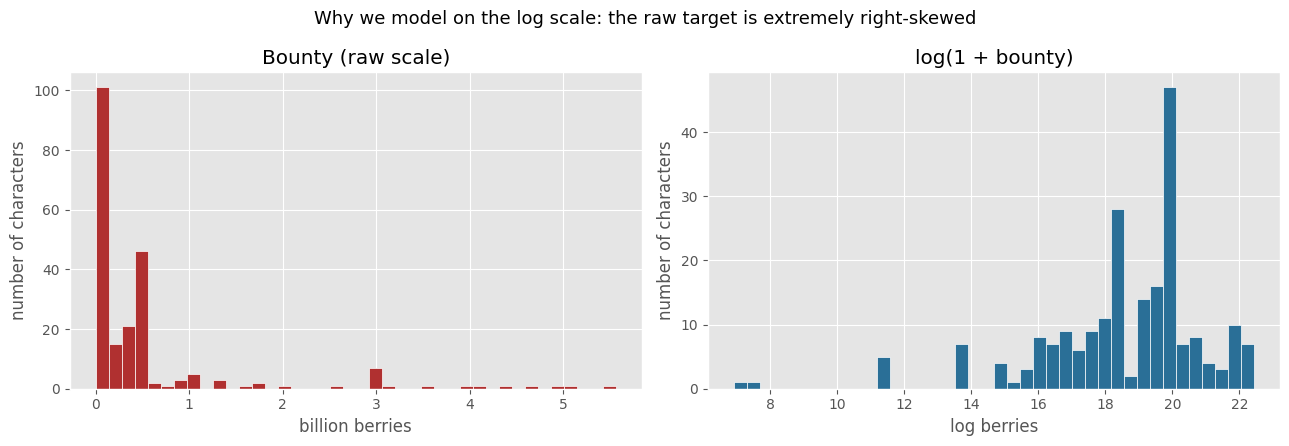

In [ ]:
b = parsed_df.loc[parsed_df['bounty'].notna(), 'bounty'].astype(float)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.hist(b / 1e9, bins=40, color='#b03030', edgecolor='white')
a1.set_title('Bounty (raw scale)'); a1.set_xlabel('billion berries'); a1.set_ylabel('number of characters')
a2.hist(np.log1p(b), bins=40, color='#2a6f97', edgecolor='white')
a2.set_title('log(1 + bounty)'); a2.set_xlabel('log berries'); a2.set_ylabel('number of characters')
fig.suptitle('Why we model on the log scale: the raw target is extremely right-skewed', fontsize=13)
fig.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התפלגות היעד, שתי סקאלות — ההצדקה לרגרסיה על log(bounty).</p>
<p>משמאל (גולמי): ~100 דמויות בפח הנמוך, זנב ארוך ודליל עד 5.56B. התפלגות מוטה-ימינה קיצונית.</p>
<p>מימין (לוגריתמי): אותם נתונים נפרשים לצורת פעמון סבירה.</p>
<p>למה זה חשוב: על הסקאלה הגולמית כמה ערכים ענקיים שולטים בשגיאה, והמודל "מתעוור" לרוב. הלוג מאזן את המשקלים, ולכן הרגרסיה והמדדים (R², RMSE) מחושבים עליו.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חוק ציפף (Zipf) — היכרות עם הקורפוס. התפלגות תדירות המילים מול הדירוג בסקאלה לוג-לוג, לעומת העקומה האידיאלית 1/דירוג — בדיקת שפיות לקורפוס.</p>
</div>

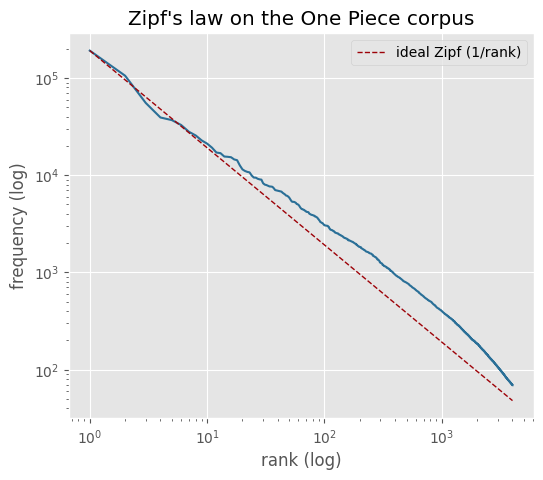

In [ ]:
counts = Counter()
for t in parsed_df['clean_text'].fillna(''):
    counts.update(re.findall(r'[a-z]{3,}', t.lower()))
freqs = np.array(sorted(counts.values(), reverse=True)[:4000], dtype=float)
ranks = np.arange(1, len(freqs) + 1)
fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(ranks, freqs, color='#2a6f97', lw=1.5)
ax.loglog(ranks, freqs[0]/ranks, '--', color='#9d0208', lw=1, label='ideal Zipf (1/rank)')
ax.set_xlabel('rank (log)'); ax.set_ylabel('frequency (log)')
ax.set_title("Zipf's law on the One Piece corpus"); ax.legend()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מה רואים: התדירויות (כחול) צמודות לקו 1/דירוג (אדום) — הקורפוס מציית לחוק ציפף.</p>
<p>הסטייה הקלה באמצע ובזנב צפויה מטקסט אמיתי (Zipf-Mandelbrot), לא באג.</p>
<p>מסקנה: הטקסט מתנהג כשפה טבעית תקינה, מה שמצדיק את ייצוגי הטקסט (TF-IDF) במודל.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>השוואת שלושת המשטרים. evaluate מריץ text / network / combined על אותם 5 קיפולים מרובדים (לפי רבעון bounty).</p>
<p>כל טרנספורמציה (TF-IDF+SVD, one-hot) מותאמת על קיפול האימון בלבד — אין דליפה בין הקיפולים. כולל קו-בסיס של חציון.</p>
</div>

In [ ]:
results, oof = evaluate(
    parsed_df, regimes=('text', 'network', 'combined'),
    n_splits=5, use_embeddings=False, verbose=True)
results.round(3)

  [text    ] fold 1/5  train=174 test=44 feats=51
  [text    ] fold 2/5  train=174 test=44 feats=51
  [text    ] fold 3/5  train=174 test=44 feats=51
  [text    ] fold 4/5  train=175 test=43 feats=51
  [text    ] fold 5/5  train=175 test=43 feats=51
  [network ] fold 1/5  train=174 test=44 feats=6
  [network ] fold 2/5  train=174 test=44 feats=6
  [network ] fold 3/5  train=174 test=44 feats=6
  [network ] fold 4/5  train=175 test=43 feats=6
  [network ] fold 5/5  train=175 test=43 feats=6
  [combined] fold 1/5  train=174 test=44 feats=108
  [combined] fold 2/5  train=174 test=44 feats=108
  [combined] fold 3/5  train=174 test=44 feats=108
  [combined] fold 4/5  train=175 test=43 feats=109
  [combined] fold 5/5  train=175 test=43 feats=110

=== CV results (mean over folds) — engine: CatBoost ===
                   R2_log  RMSE_log     MAE_berries
model                                              
baseline (median)  -0.050     2.516 503,735,138.662
text                0.367     1.953 3

,R2_log,RMSE_log,MAE_berries
model,,,
baseline (median),-0.050,2.516,"503,735,138.662"
text,0.367,1.953,"314,059,483.038"
network,0.131,2.289,"479,356,273.129"
combined,0.424,1.863,"303,450,059.331"


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ויזואליזציה של תוצאות ההשוואה: תרשים עמודות של R² (על היעד הלוגריתמי) לכל אחד משלושת המשטרים מול קו-הבסיס, עם הערך המספרי מעל כל עמודה.</p>
</div>

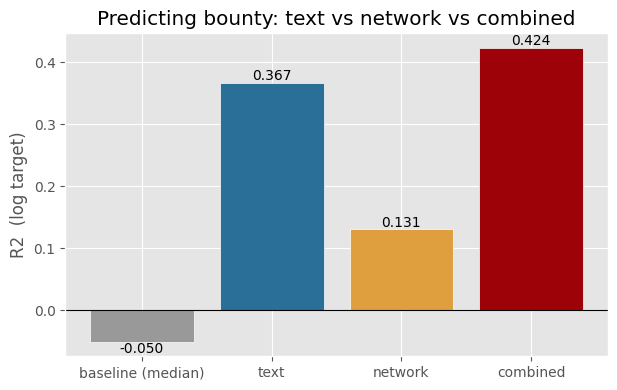

In [ ]:
order = ['baseline (median)', 'text', 'network', 'combined']
r = results.reindex([m for m in order if m in results.index])
colours = {'baseline (median)': '#999999', 'text': '#2a6f97',
           'network': '#e09f3e', 'combined': '#9d0208'}
fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(r.index, r['R2_log'], color=[colours[m] for m in r.index], edgecolor='white')
ax.axhline(0, color='black', lw=0.8); ax.set_ylabel('R2  (log target)')
ax.set_title('Predicting bounty: text vs network vs combined')
for bar, v in zip(bars, r['R2_log']):
    ax.text(bar.get_x() + bar.get_width()/2, v, f'{v:.3f}',
            ha='center', va='bottom' if v >= 0 else 'top')
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגרף משווה R² על היעד הלוגריתמי בין שלושת המשטרים לקו-הבסיס. R² מודד כמה מהשונות ב-log(bounty) המודל מסביר — גבוה יותר = טוב יותר; 0 = כמו ניחוש הממוצע; שלילי = גרוע מהבסיס.</p>
<p>קו-הבסיס (חציון): מעט מתחת לאפס (−0.050), כצפוי ממנבא תמים.</p>
<p>טקסט בלבד: 0.367 — לטקסט של דף הוויקי אות חזק על ה-bounty.</p>
<p>רשת בלבד: 0.131 — למיקום ברשת יש אות, אך חלש בהרבה מהטקסט.</p>
<p>משולב: 0.424 — הגבוה ביותר, ומנצח את הטקסט לבדו. זו התשובה לשאלת המחקר: הטקסט והרשת נושאים אות משלים, והשילוב הוא המנבא הטוב ביותר.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>רשת הדמויות. צומת = דמות; קשת = שיתוף קבוצה.</p>
<p>מוצג: 3-core של הרכיב הגדול (אחרי גיזום עלים) + כל בעלי ה-bounty — שומר גם דמויות פריפריאליות חשובות, בלי לכפות שם.</p>
<p>גודל = מספר קשרים (לוג); צבע = bounty; אפור דהוי = בלי bounty (רקע). מתויגות 30 הגבוהות.</p>
</div>

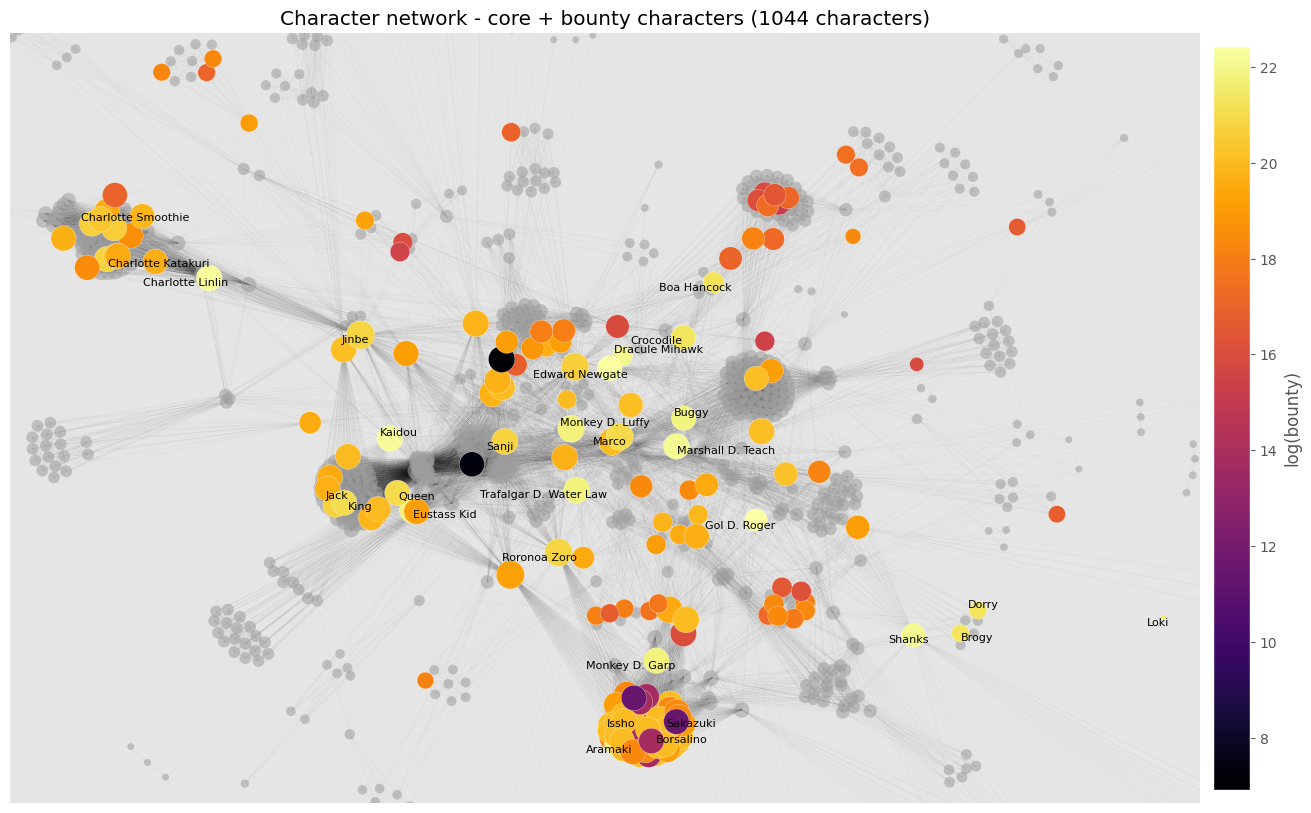

In [ ]:
H = character_network(G, parsed_df)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מה רואים: בעלי ה-bounty הגבוה (לופי, רוג'ר, ניוגייט, שאנקס) בליבה הצפופה; חסרי bounty (אפור) ואשכולות פריפריאליים בחוץ.</p>
<p>אשכולות: משפחת שארלוט (שמאל-עליון), אדמירלים/מרינס (תחתון), הענקים דורי/ברוגי/לוקי (ימין).</p>
<p>מסקנה: מרכזיוּת מתואמת עם bounty → מאפייני הגרף נושאים אות חיזוי, הבסיס למשטר ה"רשת".</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>רשת הקבוצות. כל צומת = צוות/ארגון; קשת בין שתיים = חברים משותפים, ומשקלה = מספר הדמויות המשותפות.</p>
<p>גודל הצומת = מספר החברים (מנורמל בשורש), צבע הצומת = חציון ה-bounty בקבוצה. מוצגים אשכולות עם 3 קבוצות ומעלה, במיקוד על המסה המרכזית.</p>
</div>

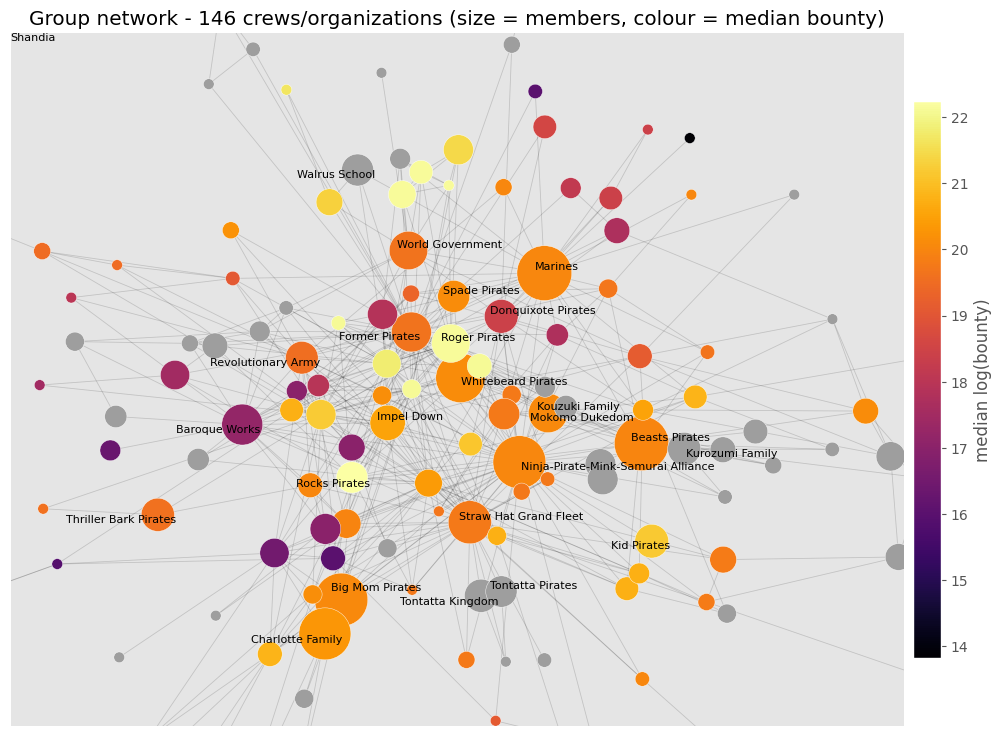

In [ ]:
GG = group_network(parsed_df)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מה רואים: 146 צוותים/ארגונים, צבע = חציון log(bounty), גודל = מספר חברים.</p>
<p>הצמתים הגדולים (הרבה חברים): מארינס, משפחת שארלוט, ביג מאם, חיות הפרא.</p>
<p>הבהירים ביותר (chציון bounty גבוה): הצוותים האגדיים — רוג'ר, זקן לבן, רוקס — יושבים במרכז.</p>
<p>אפור = אין חבר עם bounty בקבוצה (חציון לא מוגדר).</p>
<p>מרכז צפוף = הארגונים הגדולים והמקושרים; פריפריה = קבוצות קטנות/מבודדות.</p>
<p>מסקנה: צוותי ה-bounty הגבוה גם מרכזיים וגם מקושרים — מיקום ברשת מתואם עם bounty, ולכן אות הרשת תורם למודל.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח שגיאות (דרישת קורס: לפחות 10 דוגמאות). הדמויות שהמודל המשולב שגה בהן ביותר, לפי גודל השארית בסקאלה הלוגריתמית.</p>
</div>

In [ ]:
error_analysis(oof, regime='combined', n=12)

,name,bounty,pred_bounty,resid_log,direction
0,Tony Tony Chopper,1000,469082332,13.060,over-predicted
1,Bepo,1500,214884087,11.870,over-predicted
2,Asahija,100000,121684668,7.100,over-predicted
3,Mashikaku,100000,31162517,5.740,over-predicted
4,Shine,100000,25718813,5.550,over-predicted
5,Lines,100000,20126453,5.300,over-predicted
6,Makko,1000000,94142754,4.540,over-predicted
7,Zotto,1000000,88648522,4.480,over-predicted
8,Isuka,1000000,87346537,4.470,over-predicted
9,Stalker,1000000,71202261,4.270,over-predicted


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אותן שגיאות על גרף החיזוי מול האמת (out-of-fold). נקודה מעל הקו המקווקו = חיזוי-יתר, מתחתיו = חיזוי-חסר, והמרחק מהקו = גודל השגיאה.</p>
<p>החיזויים-יתר הגדולים הם דמויות חלשות בצוותים חזקים (צ'ופר, בפו) — בדיוק הפער בין מיקום ברשת לעוצמה אישית שהפרויקט חוקר.</p>
</div>

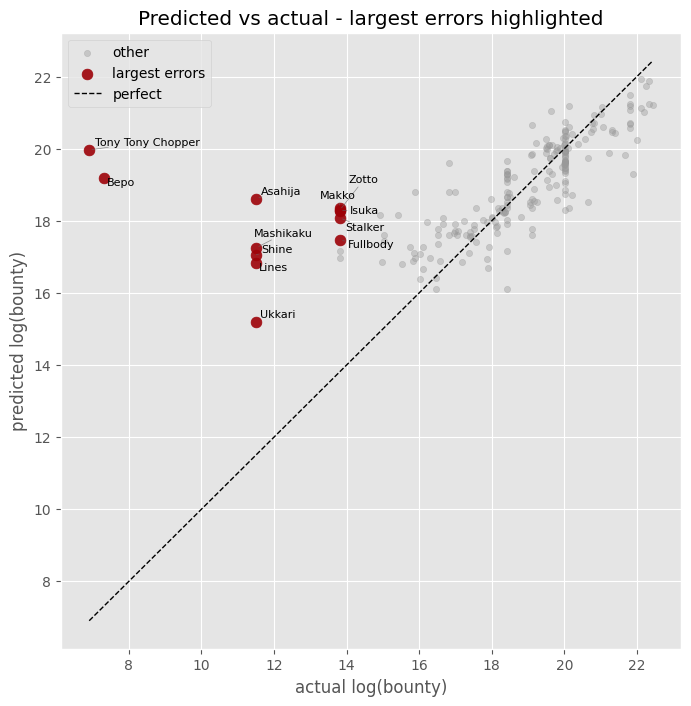

In [ ]:
err = error_analysis(oof, regime='combined', n=12)
err_names = set(err['name'])

yt = oof['y_log'].values
yp = oof['pred_log_combined'].values
is_err = oof['name'].isin(err_names).values

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(yt[~is_err], yp[~is_err], s=20, alpha=0.4, color='#999999', label='other')
ax.scatter(yt[is_err], yp[is_err], s=60, alpha=0.9, color='#9d0208', label='largest errors')
lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
ax.plot([lo, hi], [lo, hi], '--', color='black', lw=1, label='perfect')
texts = [ax.text(row['y_log'], row['pred_log_combined'], row['name'], fontsize=8)
         for _, row in oof[is_err].iterrows()]
adjust_text(texts, ax=ax, expand=(1.2, 1.5),
            arrowprops=dict(arrowstyle='-', color='0.4', lw=0.5, alpha=0.7))
ax.set_xlabel('actual log(bounty)'); ax.set_ylabel('predicted log(bounty)')
ax.set_title('Predicted vs actual - largest errors highlighted'); ax.legend()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח שגיאות (out-of-fold): 12 הטעויות הגדולות של המשולב, לפי השארית הלוגריתמית. הטבלה מפרטת, הגרף ממקם.</p>
<p>כל 12 הן חיזוי-יתר — אפס חיזוי-חסר. מצב הכשל: ניפוח דמויות חלשות, לא החמצת דמויות חזקות.</p>
<p>קיצוניות: צ'ופר (1,000 → ~469M) ובפו (1,500 → ~215M) — באונטי-בדיחה, אבל חברי כובע הקש/פיראטי הלב, אז הרשת מושכת מעלה.</p>
<p>בגרף: מעל הקו = חיזוי-יתר. כל הנקודות האדומות גבוה משמאל (באונטי אמיתי נמוך), האפורות צמודות לקו.</p>
<p>המשמעות: הפער בין מיקום ברשת לעוצמה אישית — בדיוק מה שהווריאנט המשוקלל מנסה לאזן.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>וריאנט משוקלל — איזון הקצה הגבוה. הרגרסיה נוטה לכווץ דמויות-עוצמה לכיוון הממוצע (מעט דוגמאות גבוהות מאוד).</p>
<p>make_sample_weights נותן משקל-יתר ליונקו, לשיצ'יבוקאי ולרבעון העליון של ה-bounty. ההערכה הראשית נשארת לא-משוקללת (השוואה כנה); זה ווריאנט מדווח.</p>
<p>הערה: גורוסיי ואימו אינם ניתנים לשקלול (אין להם bounty, הם בצד החיזוי בלבד), אז השקלול מעלה חיזוי לפרופילים דומים בלבד.</p>
</div>

In [ ]:
results_w, oof_w = evaluate(
    parsed_df, regimes=('text', 'network', 'combined'),
    n_splits=5, use_embeddings=False, weight_fn=make_sample_weights, verbose=False)

cmp = results[['R2_log']].rename(columns={'R2_log': 'R2_unweighted'})
cmp['R2_weighted'] = results_w['R2_log']
print("Effect of up-weighting the top tier (R2 on the log target):")
cmp.round(3)

Effect of up-weighting the top tier (R2 on the log target):


,R2_unweighted,R2_weighted
model,,
baseline (median),-0.050,-0.050
text,0.367,0.355
network,0.131,0.121
combined,0.424,0.397


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מה רואים: השקלול דווקא מוריד את ה-R² בכל המשטרים (המשולב: 0.424 → 0.397). ההסבר: רוב הדמויות בינוניות, והמדד הכולל נשלט על ידן — שיפור הקצה הגבוה בא על חשבון הרוב. ממצא שלילי מעניין: הפער בין קצה ההתפלגות למרכזה הוא מגבלה מובנית של המדגם, לא כשל של המודל.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת עמידות שנייה — יעד נקי. חלק מ"הבאונטי" הם דירוגי-כוח של הממשלה בפורמט באונטי ({{B|s}} למרינס, {{C|N}} מהקרוס גילד) ולא באונטי מבוקש אמיתי. wanted_only=True משמיט אותם ומריץ את ההשוואה על באונטי {{B}} רגיל בלבד — בדיקה שהמסקנה אינה תלויה בזיהום היעד.</p>
</div>

In [ ]:
results_wo, oof_wo = evaluate(
    parsed_df, regimes=('text', 'network', 'combined'),
    n_splits=5, use_embeddings=False, wanted_only=True, verbose=False)

cmp2 = results[['R2_log']].rename(columns={'R2_log': 'R2_all_bounties'})
cmp2['R2_wanted_only'] = results_wo['R2_log']
print("All bounties vs plain {{B}} wanted bounties only (R2 on the log target):")
cmp2.round(3)

All bounties vs plain {{B}} wanted bounties only (R2 on the log target):


,R2_all_bounties,R2_wanted_only
model,,
baseline (median),-0.050,-0.012
text,0.367,0.324
network,0.131,0.151
combined,0.424,0.361


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מה רואים: על היעד הנקי ה-R² יורד מעט (המשולב: 0.424 → 0.361) — צפוי, כי הוסרו דוגמאות. המעניין: הרשת דווקא משתפרת (0.131 → 0.151) — דירוגי הממשלה היו רעש עבורה. והעיקר: הדירוג נשמר — משולב > טקסט > רשת > בסיס בשתי הריצות. המסקנה המרכזית עמידה גם לשקלול וגם לניקוי היעד.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>יישום: הרצת המודל המשולב על דמויות בולטות שאין להן באונטי רשמי, לאמידת הערך החזוי שלהן. המודל אומן על הדמויות בעלות ה-bounty, וכאן מופעל על מועמדים שמעולם לא הוכרז להם באונטי (בקמן, חברי הגורוסיי, אדמירלים לשעבר).</p>
<p>הפיצ'רים נבנים דרך אותן פונקציות של modeling.py — אימון על המתויגות, חיזוי על המועמדים, בלי דליפה. הדגמה בלבד, לא חלק מההערכה: אין לדמויות אלו ערך אמת.</p>
</div>

In [ ]:
candidates = ['Benn Beckman', 'Marcus Mars', 'Ethanbaron V. Nusjuro',
              'Shepherd Ju Peter', 'Jaygarcia Saturn', 'Topman Warcury',
              'Lucky Roux', 'Yasopp', 'Silvers Rayleigh',
              'Sengoku', 'Kong', 'Kuzan']

train = parsed_df[parsed_df['bounty'].notna() & ~parsed_df['is_crew']].copy()
pool = parsed_df[parsed_df['name'].isin(candidates)].copy()
pool = pool[~pool['name'].isin(train['name'])]

Xtr, Xte = build_fold_matrix('combined', train, pool, use_embeddings=False)
y = np.log1p(train['bounty'].astype(float).values)

reg, _ = make_regressor()
reg.fit(Xtr, y)
pred = np.expm1(reg.predict(Xte))

out = pd.DataFrame({'name': pool['name'].values, 'predicted_bounty': pred.round(-6).astype('int64')})
out = out.sort_values('predicted_bounty', ascending=False).reset_index(drop=True)
out['predicted_bounty'] = out['predicted_bounty'].map(lambda x: f'{x:,}')
out

,name,predicted_bounty
0,Sengoku,"2,456,000,000"
1,Kuzan,"1,719,000,000"
2,Ethanbaron V. Nusjuro,"1,463,000,000"
3,Topman Warcury,"1,351,000,000"
4,Kong,"1,323,000,000"
5,Marcus Mars,"1,135,000,000"
6,Silvers Rayleigh,"1,124,000,000"
7,Jaygarcia Saturn,"1,109,000,000"
8,Shepherd Ju Peter,"1,083,000,000"
9,Benn Beckman,"221,000,000"


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מה רואים: התחזיות מסתדרות לפי הפרופיל — דמויות עם היסטוריית עוצמה מתועדת וקישוריות גבוהה (ריילי, סנגוקו, קוזאן) מקבלות אומדנים גבוהים, בעוד דמויות מתועדות-פחות מקבלות אומדנים צנועים. עבור הגורוסיי האומדנים כנראה שמרניים מדי — הם מחוץ להתפלגות האימון (עוצמה פוליטית עצומה, תיעוד קרבי מועט), בדיוק סוג מקרה הקצה שהוזכר בהערת השקלול. אין ערכי אמת, אז זו בחינת סבירות בלבד.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מסקנות:</p>
<ul>
<li>שאלת המחקר נענתה: המודל המשולב (טקסט + רשת) מנבא הכי טוב; הטקסט לבדו חזק מהרשת לבדה, והשילוב מנצח — האותות משלימים.</li>
<li>תובנה מרכזית (מניתוח השגיאות): הטעויות הגדולות הן דמויות חלשות בצוותים חזקים (צ'ופר, בפו) — הרשת מנפחת את תחזיתן. זה הפער בין מיקום ברשת לעוצמה אישית, שהמשולב מאזן ברוב המקרים.</li>
<li>עמידות: המסקנה נשמרת בשתי בדיקות — שקלול הקצה הגבוה מוריד מעט את ה-R² הכולל (הרוב הבינוני שולט במדד), והרצה על באונטי מבוקש בלבד שומרת על אותו דירוג משטרים; הרשת אף משתפרת על היעד הנקי.</li>
<li>הנתונים נאספו ונוקו בעצמנו מ-Fandom Wiki: חילוץ bounty מהטקסט, סינון דפים שאינם דמויות ודמויות לא-קנוניות — 218 רשומות עם Bounty ידוע, כולן דמויות בודדות המשמשות לאימון (דפי הצוותים סוננו עוד בשלב הפענוח).</li>
<li>מגבלות: מעט דמויות מתויגות (218 לאימון), ולכן Gradient Boosting היציב על דאטה קטן; חלק מהדמויות החזקות חסרות Bounty רשמי (טופלו כאפליקציה).</li>
<li>אפליקציה: המודל הופעל על דמויות חזקות חסרות-Bounty וסיפק תחזיות סבירות לפי הפרופיל.</li>
<li>איכות נתונים: כ-30% מה-bounty אינם באונטי מבוקש אלא דירוגי-כוח של הממשלה — 61 דירוגי מרינס ({{B|s}}, ★=100M) ו-5 קרוס-גילד ({{C|N}}, ★=מיליארד). מסומנים ב-is_star_bounty, נשמרים כעמודה אחת אך אינם מוזנים למודל. evaluate(wanted_only=True) מאמן רק על המבוקשים.</li>
</ul>
</div>